# MRSI Data Analysis Tutorial

This notebook demonstrates how to:
1. Load Siemens MRSI DICOM data
2. Visualize spatial and spectral dimensions
3. Extract and analyze spectroscopy data from individual voxels
4. Apply phase correction to improve spectral quality
5. Transform between time and frequency domains using FFT

**Required Libraries:**
- pydicom: For reading DICOM files
- nibabel: For NIfTI file support
- nmrglue: For spectroscopy data processing and phase correction
- numpy, scipy, matplotlib: For numerical processing and visualization


In [20]:
#What libraries do you need?
import pandas as pd
import numpy as np
from scipy import stats as st
import seaborn as sns
import matplotlib.pyplot as plt
import pydicom
from pydicom.data import get_testdata_files
import nibabel as nib
import nipype
import nmrglue as ng


## 1. Loading Siemens MRSI DICOM Data

Siemens stores spectroscopy data in private DICOM tags. The data is typically stored as:
- Multiple DICOM files (one per slice)
- Complex data (real + imaginary) stored as float32 pairs
- Private tag (0x7fe1, 0x1010) contains the spectroscopy data

We'll load all files and reconstruct the 4D matrix: (slices, x, y, spectral_points)


In [21]:
# Load Siemens MRSI DICOM data - Build 4D matrix
import os
import glob

# Path to DICOM directory
dicom_dir = '/Users/bbbartel/ASU Dropbox/Benjamin Bartelle/M.A.P.S._Data/DICOM Siemens/MRSI:FLAIR data/RMS01_MRSI/WIP_3D_MRS_SI_REF_0020'

# Get all DICOM files and sort them
dicom_files = sorted(glob.glob(os.path.join(dicom_dir, '*.IMA')))
print(f"Found {len(dicom_files)} DICOM files")

# Tag for Siemens spectroscopy data
spec_tag = (0x7fe1, 0x1010)

# Load all files and extract spectroscopy data
mrsi_slices = []
for i, dcm_file in enumerate(dicom_files):
    ds = pydicom.dcmread(dcm_file)
    
    # Get spectroscopy data
    if spec_tag in ds:
        spec_data = ds[spec_tag].value
        
        # Convert to float32 array then to complex64
        spec_float = np.frombuffer(spec_data, dtype=np.float32)
        spec_complex = spec_float.view(np.complex64)
        
        # Reshape to 64x64x512
        spec_3d = spec_complex.reshape(64, 64, 512)
        mrsi_slices.append(spec_3d)
        
        if i == 0:
            print(f"\nFirst file processed:")
            print(f"  Raw data: {len(spec_data)} bytes")
            print(f"  Float32 array: {spec_float.shape}")
            print(f"  Complex64 array: {spec_complex.shape}")
            print(f"  Reshaped to 3D: {spec_3d.shape}")

# Stack all slices into 4D array
mrsi_4d = np.stack(mrsi_slices, axis=0)

print(f"\n{'='*50}")
print(f"Final MRSI 4D matrix shape: {mrsi_4d.shape}")
print(f"Expected shape: (32, 64, 64, 512)")
print(f"Shapes match: {mrsi_4d.shape == (32, 64, 64, 512)}")
print(f"Data type: {mrsi_4d.dtype}")
print(f"{'='*50}")


Found 32 DICOM files

First file processed:
  Raw data: 16777216 bytes
  Float32 array: (4194304,)
  Complex64 array: (2097152,)
  Reshaped to 3D: (64, 64, 512)

Final MRSI 4D matrix shape: (32, 64, 64, 512)
Expected shape: (32, 64, 64, 512)
Shapes match: True
Data type: complex64


## 2. Creating a 3D Spatial Image

To visualize the spatial distribution of signal, we can average across the spectral dimension (4th dimension).
This creates a 3D image showing which voxels contain signal.

We use the **absolute value** of the complex data before averaging, since the magnitude represents signal strength regardless of phase.


3D image shape after averaging: (32, 64, 64)
Data type: float32


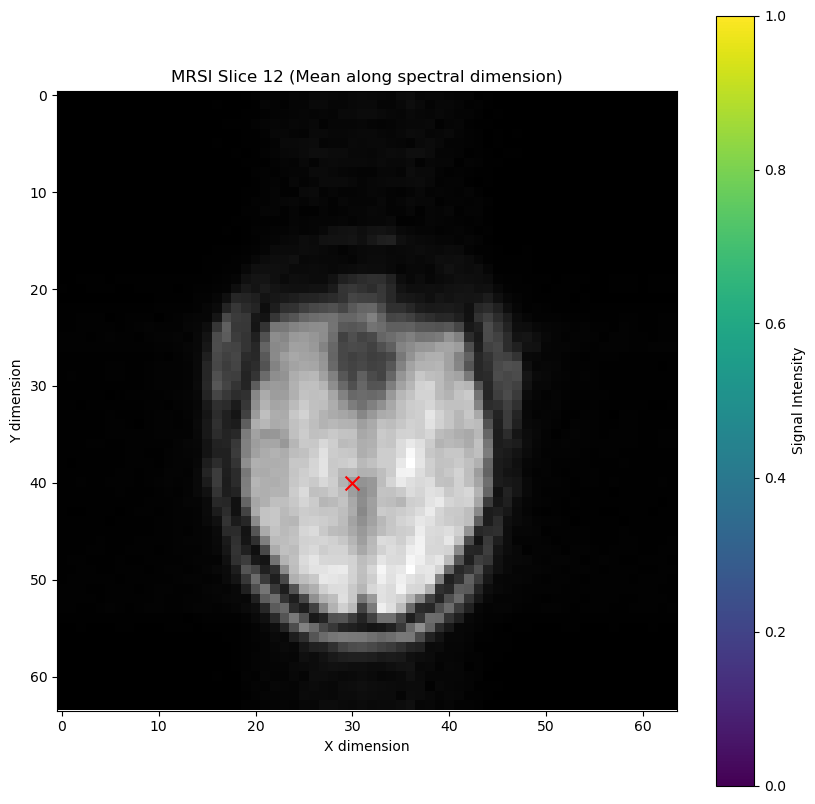

In [22]:
# Take mean along 4th dimension (spectral dimension) - use absolute value for complex data
mrsi_3d = np.mean(np.abs(mrsi_4d), axis=3)

print(f"3D image shape after averaging: {mrsi_3d.shape}")
print(f"Data type: {mrsi_3d.dtype}")

# Display slice 12 with the voxel location marked
plt.figure(figsize=(10, 10))
plt.imshow(mrsi_3d[12, :, :], cmap='gray')
plt.scatter(30, 40, c='red', s=100, marker='x')  # Mark voxel (12, 40, 30)
plt.title('MRSI Slice 12 (Mean along spectral dimension)')
plt.colorbar(label='Signal Intensity')
plt.xlabel('X dimension')
plt.ylabel('Y dimension')
plt.show()


## 3. Extracting FID Data from a Single Voxel

Now we'll extract the FID (Free Induction Decay) from a specific voxel location (12, 40, 30).

The raw MRSI data is stored in the **time domain** as the FID - the actual signal acquired from the scanner.
The FID contains 512 complex data points representing the time-domain signal.

**Key concepts:**
- FID = Time domain signal that decays over time
- Real and imaginary parts correspond to the in-phase and out-of-phase signal components
- Magnitude = sqrt(real² + imaginary²) gives the signal strength
- To see metabolite peaks, we need to FFT the FID to frequency domain


FID shape: (512,)
Data type: complex64


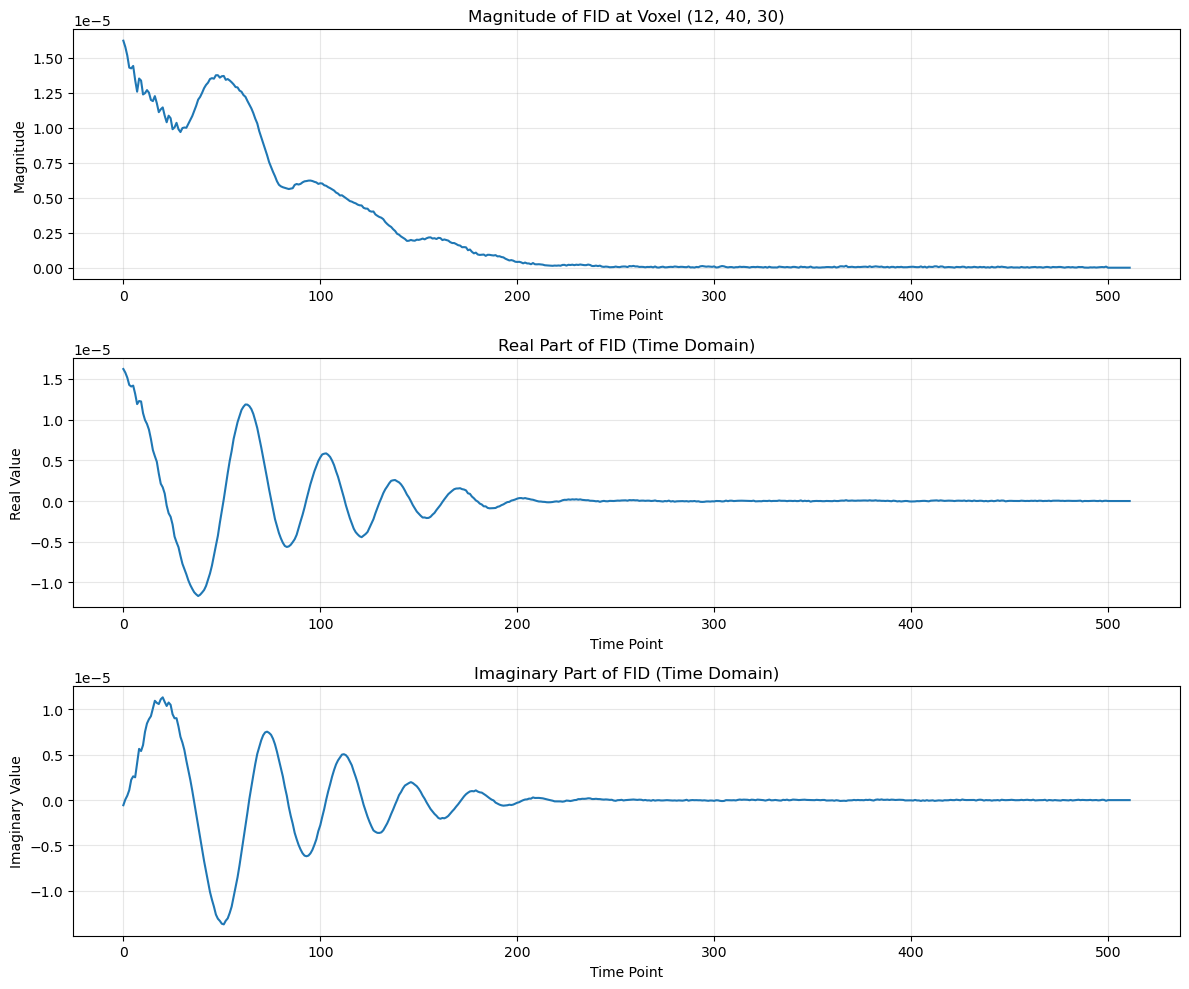

In [36]:
# Extract FID (time domain) at voxel (12, 40, 30)
fid = mrsi_4d[12, 40, 30, :]

print(f"FID shape: {fid.shape}")
print(f"Data type: {fid.dtype}")

# Plot the FID (time domain signal)
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Plot magnitude
axes[0].plot(np.abs(fid))
axes[0].set_title('Magnitude of FID at Voxel (12, 40, 30)')
axes[0].set_xlabel('Time Point')
axes[0].set_ylabel('Magnitude')
axes[0].grid(True, alpha=0.3)

# Plot real part
axes[1].plot(np.real(fid))
axes[1].set_title('Real Part of FID (Time Domain)')
axes[1].set_xlabel('Time Point')
axes[1].set_ylabel('Real Value')
axes[1].grid(True, alpha=0.3)

# Plot imaginary part
axes[2].plot(np.imag(fid))
axes[2].set_title('Imaginary Part of FID (Time Domain)')
axes[2].set_xlabel('Time Point')
axes[2].set_ylabel('Imaginary Value')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 4. FFT to Convert FID to Spectrum (Without Phase Correction)

Now we'll transform the time domain FID into a frequency domain spectrum using FFT.

In MRS processing:
- **Time domain** = Free Induction Decay (FID) - the raw signal acquired from the scanner
- **Frequency domain** = Spectrum - shows peaks at different metabolite frequencies

**FFT (Fast Fourier Transform)** converts time domain FID → frequency domain spectrum.

**Note:** Without proper phase correction, the spectrum may have mixed positive/negative peaks.


Spectrum shape: (512,)
Data type: complex64


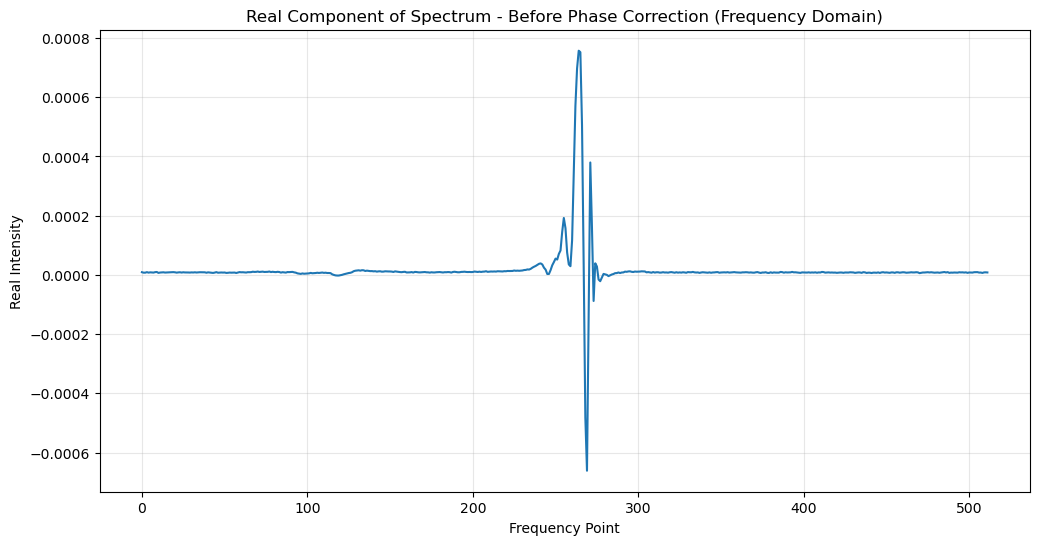

In [37]:
# Use nmrglue to FFT the FID to get frequency domain spectrum (before phase correction)
spectrum = ng.proc_base.fft(fid)

print(f"Spectrum shape: {spectrum.shape}")
print(f"Data type: {spectrum.dtype}")

# Plot the real component of the spectrum
plt.figure(figsize=(12, 6))
plt.plot(np.real(spectrum))
plt.title('Real Component of Spectrum - Before Phase Correction (Frequency Domain)')
plt.xlabel('Frequency Point')
plt.ylabel('Real Intensity')
plt.grid(True, alpha=0.3)
plt.show()


## 5. Phase Correction for Optimal Spectral Quality

**Why phase correction is important:**
In MRS, imperfect timing and hardware delays cause the signal to have incorrect phase. This results in:
- Mixed positive/negative peaks in the real spectrum
- Energy spread between real and imaginary components
- Difficulty in quantifying metabolite concentrations

**Phase correction parameters:**
- **Zero-order phase (p0)**: Constant phase shift applied to all frequencies
- **First-order phase (p1)**: Linear phase gradient across the spectrum

**Our approach:**
We'll optimize both p0 and p1 to minimize negative values in the real spectrum, producing a clean absorption-mode spectrum where metabolite peaks are predominantly positive.


Optimized phase parameters: p0=10.53°, p1=-12.49°


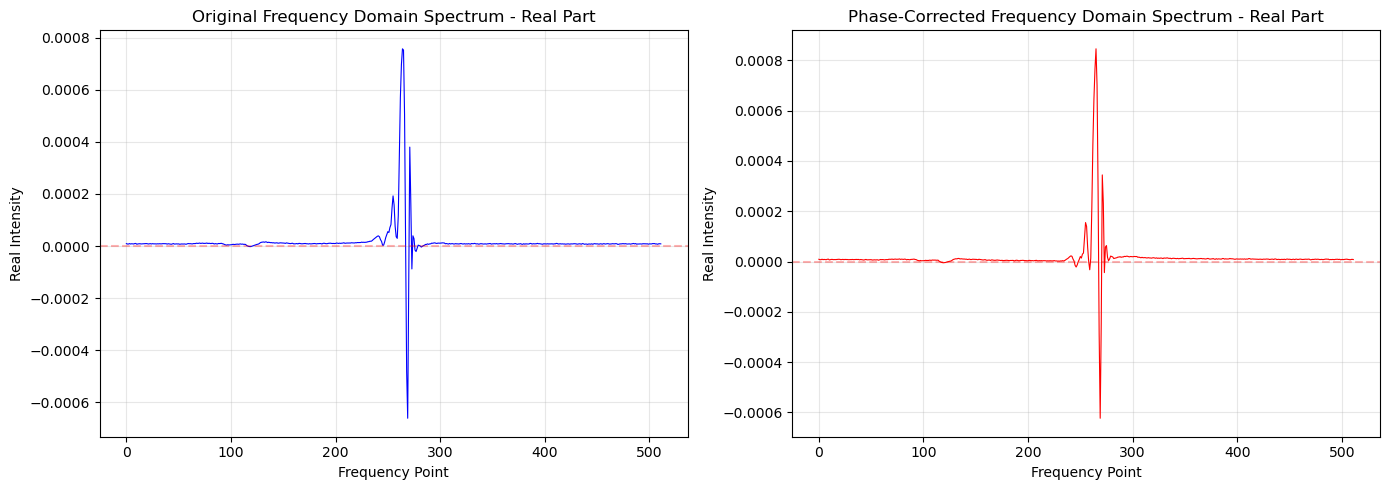


Negative value reduction in frequency domain:
Original spectrum - Negative sum: -1.440297e-03
Phase-corrected spectrum - Negative sum: -1.309390e-03


In [39]:
# Phase correction optimization
import nmrpy
from scipy.optimize import minimize

# Step 1: Convert frequency domain spectrum to time domain FID
fid_nmr = ng.proc_base.ifft(spectrum)

# Step 2: Define optimization function to minimize negative values in the frequency domain spectrum
def objective_minimize_negative(phases):
    p0, p1 = phases
    # Apply phase correction to time domain FID
    n = len(fid_nmr)
    pivot = n // 2
    phase_array = p0 + p1 * np.linspace(-pivot, n-pivot-1, n) / n
    fid_corrected = fid_nmr * np.exp(1j * np.deg2rad(phase_array))
    # FFT back to frequency domain spectrum
    spectrum_corrected = ng.proc_base.fft(fid_corrected)
    # Objective: minimize sum of negative values in the real part
    real_spectrum = np.real(spectrum_corrected)
    penalty = -np.sum(real_spectrum[real_spectrum < 0])
    return penalty

# Step 3: Optimize phase parameters
result = minimize(objective_minimize_negative, x0=[0, 0], method='Nelder-Mead')
p0_opt, p1_opt = result.x

print(f"Optimized phase parameters: p0={p0_opt:.2f}°, p1={p1_opt:.2f}°")

# Step 4: Apply optimal phase correction to time domain FID
n = len(fid_nmr)
pivot = n // 2
phase_array = p0_opt + p1_opt * np.linspace(-pivot, n-pivot-1, n) / n
fid_optimized = fid_nmr * np.exp(1j * np.deg2rad(phase_array))

# Step 5: FFT back to frequency domain spectrum
spectrum_optimized = ng.proc_base.fft(fid_optimized)

# Plot comparison - Frequency Domain Spectra
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original frequency domain spectrum
axes[0].plot(np.real(spectrum), 'b-', linewidth=0.8)
axes[0].set_title('Original Frequency Domain Spectrum - Real Part')
axes[0].set_xlabel('Frequency Point')
axes[0].set_ylabel('Real Intensity')
axes[0].axhline(y=0, color='r', linestyle='--', alpha=0.3)
axes[0].grid(True, alpha=0.3)

# Phase-corrected frequency domain spectrum
axes[1].plot(np.real(spectrum_optimized), 'r-', linewidth=0.8)
axes[1].set_title('Phase-Corrected Frequency Domain Spectrum - Real Part')
axes[1].set_xlabel('Frequency Point')
axes[1].set_ylabel('Real Intensity')
axes[1].axhline(y=0, color='r', linestyle='--', alpha=0.3)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate statistics
print(f"\nNegative value reduction in frequency domain:")
print(f"Original spectrum - Negative sum: {np.sum(np.real(spectrum)[np.real(spectrum) < 0]):.6e}")
print(f"Phase-corrected spectrum - Negative sum: {np.sum(np.real(spectrum_optimized)[np.real(spectrum_optimized) < 0]):.6e}")


## 6. Additional Processing Techniques (Optional)

Several additional techniques are commonly used in MRS processing, though they are not necessary for this dataset:

### Spectrum Centering (fftshift)
In some cases, the FFT output may place zero frequency at the edges rather than the center. Using `np.fft.fftshift` would center the spectrum, placing the carrier frequency in the middle (point 256).

**When fftshift is needed:**
- After significant phase correction that shifts the spectrum
- When the FFT convention places DC at the edges
- To follow standard NMR/MRS display conventions with carrier at center

### Apodization
Apodization applies a smoothing window to the FID (time domain) to reduce noise and improve line shape in the spectrum.

**Common apodization functions:**
- Exponential (line broadening): `ng.proc_base.em(fid, lb=5.0)`
- Gaussian: `ng.proc_base.gm(fid, g1=0, g2=0.1)`

**When apodization helps:**
- Noisy data with poor signal-to-noise ratio
- To reduce oscillations/ringing in the spectrum
- Trade-off: improves appearance but may broaden peaks

### Zero-Filling
Zero-filling pads the FID with zeros before FFT, increasing the number of points in the spectrum for smoother visualization.

**When zero-filling helps:**
- Improve spectral interpolation for display
- Better peak visualization without changing actual resolution
- Typically pad to 2x or 4x original size

**In this case:** Since this data has good quality with minimal phase error and adequate resolution, these additional processing steps are not necessary. The spectrum is ready for metabolite analysis as-is.


## 7. Transform Full Dataset: FID to Spectrum

Now let's apply the FFT transformation to the entire 4D MRSI dataset to convert all FIDs to frequency-domain spectra.

This creates a spectral dataset where each voxel contains a frequency-domain spectrum instead of a time-domain FID, making it ready for metabolite quantification across all brain regions.

Original MRSI dataset (FID - Time Domain):
  Shape: (32, 64, 64, 512)
  Data type: complex64
  Size: 512.00 MB

Processing 131072 FIDs...

Transformed MRSI dataset (Spectra - Frequency Domain):
  Shape: (32, 64, 64, 512)
  Data type: complex128
  Size: 1024.00 MB

Verification: Voxel (12,40,30) spectrum matches single-voxel FFT: True


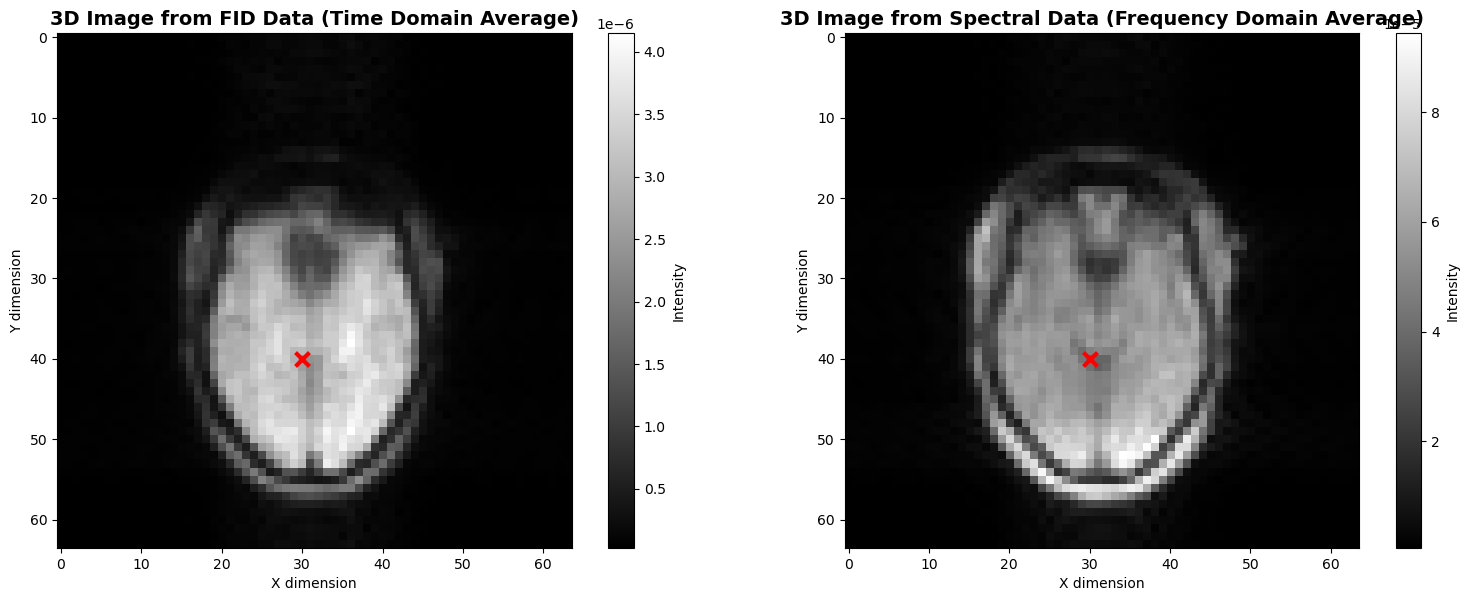


Images are identical: False


In [45]:
# Transform the entire 4D dataset from FID (time domain) to Spectrum (frequency domain)
print("Original MRSI dataset (FID - Time Domain):")
print(f"  Shape: {mrsi_4d.shape}")
print(f"  Data type: {mrsi_4d.dtype}")
print(f"  Size: {mrsi_4d.nbytes / (1024**2):.2f} MB")

# Apply FFT along the last axis (spectral dimension) for all voxels
# Reshape to 2D: (32*64*64, 512) for efficient processing
n_slices, n_rows, n_cols, n_points = mrsi_4d.shape
fids_2d = mrsi_4d.reshape(-1, n_points)  # (131072, 512)

print(f"\nProcessing {fids_2d.shape[0]} FIDs...")

# Apply FFT to each FID
spectra_2d = np.empty_like(fids_2d, dtype=complex)
for i in range(fids_2d.shape[0]):
    spectra_2d[i] = ng.proc_base.fft(fids_2d[i])
    
# Reshape back to 4D
mrsi_spectra_4d = spectra_2d.reshape(n_slices, n_rows, n_cols, n_points)

print("\nTransformed MRSI dataset (Spectra - Frequency Domain):")
print(f"  Shape: {mrsi_spectra_4d.shape}")
print(f"  Data type: {mrsi_spectra_4d.dtype}")
print(f"  Size: {mrsi_spectra_4d.nbytes / (1024**2):.2f} MB")

# Verify the transformation by comparing one voxel with our earlier work
voxel_spectrum = mrsi_spectra_4d[12, 40, 30, :]
match = np.allclose(voxel_spectrum, spectrum)

print(f"\nVerification: Voxel (12,40,30) spectrum matches single-voxel FFT: {match}")

# Create a mean spectrum image for visualization
mrsi_spectra_3d = np.mean(np.abs(mrsi_spectra_4d), axis=3)

# Display comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Original FID-based image
axes[0].imshow(mrsi_3d[12, :, :], cmap='gray')
axes[0].scatter(30, 40, c='red', s=100, marker='x', linewidths=3)
axes[0].set_title('3D Image from FID Data (Time Domain Average)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('X dimension')
axes[0].set_ylabel('Y dimension')
axes[0].colorbar = plt.colorbar(axes[0].images[0], ax=axes[0], label='Intensity')

# New spectrum-based image (should be identical)
axes[1].imshow(mrsi_spectra_3d[12, :, :], cmap='gray')
axes[1].scatter(30, 40, c='red', s=100, marker='x', linewidths=3)
axes[1].set_title('3D Image from Spectral Data (Frequency Domain Average)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('X dimension')
axes[1].set_ylabel('Y dimension')
axes[1].colorbar = plt.colorbar(axes[1].images[0], ax=axes[1], label='Intensity')

plt.tight_layout()
plt.show()

print(f"\nImages are identical: {np.allclose(mrsi_3d, mrsi_spectra_3d)}")

## 8. Saving Spectral Data as NIfTI File

The transformed spectral dataset can be saved as a NIfTI file for further analysis in other software tools.

**Important considerations:**
- NIfTI files store the data as a 4D array: (x, y, z, frequency)
- For MRSI data, the 4th dimension represents the spectral points
- Complex data (real + imaginary) needs special handling
- Option 1: Save as 5D file with real/imaginary as 5th dimension
- Option 2: Save magnitude and phase separately
- Option 3: Save real and imaginary as separate files

**Note:** The code below shows how to save but is not executed to avoid creating large files.

In [ ]:
# Example: Saving spectral data as NIfTI files (NOT EXECUTED)

# Option 1: Save real and imaginary parts separately
# This is the most common approach for complex MRS data

# Extract real and imaginary components
mrsi_spectra_real = np.real(mrsi_spectra_4d).astype(np.float32)
mrsi_spectra_imag = np.imag(mrsi_spectra_4d).astype(np.float32)

# Create NIfTI images with basic header information
# Affine matrix defines voxel spacing and orientation (identity matrix for now)
affine = np.eye(4)
affine[0, 0] = 1.0  # X voxel size (mm)
affine[1, 1] = 1.0  # Y voxel size (mm)
affine[2, 2] = 1.0  # Z voxel size (mm)

# Create NIfTI objects
nifti_real = nib.Nifti1Image(mrsi_spectra_real, affine)
nifti_imag = nib.Nifti1Image(mrsi_spectra_imag, affine)

# Save files
# nib.save(nifti_real, 'MRSI_Spectra_Real.nii')
# nib.save(nifti_imag, 'MRSI_Spectra_Imag.nii')

print("To save the files, uncomment the nib.save() lines above")
print(f"Real part shape: {mrsi_spectra_real.shape}, dtype: {mrsi_spectra_real.dtype}")
print(f"Imaginary part shape: {mrsi_spectra_imag.shape}, dtype: {mrsi_spectra_imag.dtype}")
print(f"Each file size: ~{mrsi_spectra_real.nbytes / (1024**2):.2f} MB")

# Option 2: Save magnitude and phase (useful for magnitude-only analysis)
# mrsi_spectra_mag = np.abs(mrsi_spectra_4d).astype(np.float32)
# mrsi_spectra_phase = np.angle(mrsi_spectra_4d).astype(np.float32)
# nifti_mag = nib.Nifti1Image(mrsi_spectra_mag, affine)
# nifti_phase = nib.Nifti1Image(mrsi_spectra_phase, affine)
# nib.save(nifti_mag, 'MRSI_Spectra_Magnitude.nii')
# nib.save(nifti_phase, 'MRSI_Spectra_Phase.nii')

# Option 3: Save as compressed NIfTI (.nii.gz) to reduce file size
# nib.save(nifti_real, 'MRSI_Spectra_Real.nii.gz')
# nib.save(nifti_imag, 'MRSI_Spectra_Imag.nii.gz')

# To load the data later:
# loaded_real = nib.load('MRSI_Spectra_Real.nii').get_fdata()
# loaded_imag = nib.load('MRSI_Spectra_Imag.nii').get_fdata()
# mrsi_spectra_4d_reloaded = loaded_real + 1j * loaded_imag